run on raw tweets



In [1]:
!pip install -q vaderSentiment scikit-learn pandas numpy statsmodels matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt

In [4]:
gold = pd.read_csv('tweets_gold_standard.csv')
xlm_full = pd.read_csv('xlm-roberta_results.csv')
mbert_full = pd.read_csv('mbert_results.csv')

gold['tweet_id'] = gold['tweet_id'].astype(str).str.strip()
xlm_full['tweet_id'] = xlm_full['tweet_id'].astype(str).str.strip()
mbert_full['tweet_id'] = mbert_full['tweet_id'].astype(str).str.strip()

print(f'Gold: {len(gold)} rows')
print(f'Gold columns: {list(gold.columns)}')
print(f'XLM: {len(xlm_full)} rows')
print(f'XLM columns: {list(xlm_full.columns)}')
print(f'mBERT: {len(mbert_full)} rows')
print(f'mBERT columns: {list(mbert_full.columns)}')

Gold: 498 rows
Gold columns: ['tweet_id', 'athlete_display_name', 'raw_content', 'gold_sentiment', 'final_sentiment', 'agreement_status']
XLM: 27318 rows
XLM columns: ['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'xlm-roberta_sentiment', 'xlm-roberta_score', 'xlm-roberta_original']
mBERT: 27318 rows
mBERT columns: ['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'mbert_sentiment', 'mbert_score', 'mbert_original']


In [5]:
print(list(xlm_full.columns))
print(list(mbert_full.columns))

['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'xlm-roberta_sentiment', 'xlm-roberta_score', 'xlm-roberta_original']
['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'mbert_sentiment', 'mbert_score', 'mbert_original']


In [6]:
gold_ids = set(gold['tweet_id'].values)
xlm_498 = xlm_full[xlm_full['tweet_id'].isin(gold_ids)].copy()
mbert_498 = mbert_full[mbert_full['tweet_id'].isin(gold_ids)].copy()

print(f'XLM matched to gold: {len(xlm_498)}')
print(f'mBERT matched to gold: {len(mbert_498)}')

print(f'XLM columns: {list(xlm_full.columns)}')
print(f'mBERT columns: {list(mbert_full.columns)}')
print(f'Gold sentiment values: {gold["gold_sentiment"].unique()}')

XLM matched to gold: 498
mBERT matched to gold: 498
XLM columns: ['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'xlm-roberta_sentiment', 'xlm-roberta_score', 'xlm-roberta_original']
mBERT columns: ['tweet_id', 'username', 'raw_content', 'athlete_name', 'athlete_display_name', 'translated_content', 'mbert_sentiment', 'mbert_score', 'mbert_original']
Gold sentiment values: ['positive' 'neutral' 'negative']


In [7]:
LABELS = ['positive', 'neutral', 'negative']

def normalize_label(val):
    v = str(val).strip().lower()
    mapping = {
        'positive': 'positive', 'pos': 'positive',
        'negative': 'negative', 'neg': 'negative',
        'neutral': 'neutral', 'neu': 'neutral'
    }
    return mapping.get(v, v)

df = gold[['tweet_id', 'raw_content', 'gold_sentiment']].copy()
df['gold'] = df['gold_sentiment'].apply(normalize_label)

xlm_m = xlm_498[['tweet_id', 'translated_content',
                  'xlm-roberta_sentiment',
                  'xlm-roberta_score']].copy()
xlm_m.columns = ['tweet_id', 'translated_text', 'xlm_pred', 'xlm_conf']
xlm_m['xlm_pred'] = xlm_m['xlm_pred'].apply(normalize_label)

mbert_m = mbert_498[['tweet_id',
                      'mbert_sentiment',
                      'mbert_score']].copy()
mbert_m.columns = ['tweet_id', 'mbert_pred', 'mbert_conf']
mbert_m['mbert_pred'] = mbert_m['mbert_pred'].apply(normalize_label)

df = df.merge(xlm_m, on='tweet_id', how='inner')
df = df.merge(mbert_m, on='tweet_id', how='inner')

print(f'Final merged: {len(df)} tweets')
print(f'gold NaN: {df["gold"].isna().sum()}')
print(f'xlm_pred NaN: {df["xlm_pred"].isna().sum()}')
print(f'mbert_pred NaN: {df["mbert_pred"].isna().sum()}')
print(f'translated_text NaN: {df["translated_text"].isna().sum()}')
print(f'\ngold unique: {df["gold"].unique()}')
print(f'xlm_pred unique: {df["xlm_pred"].unique()}')
print(f'mbert_pred unique: {df["mbert_pred"].unique()}')
df.head()

Final merged: 498 tweets
gold NaN: 0
xlm_pred NaN: 0
mbert_pred NaN: 0
translated_text NaN: 0

gold unique: ['positive' 'neutral' 'negative']
xlm_pred unique: ['positive' 'neutral' 'negative']
mbert_pred unique: ['positive' 'negative' 'neutral']


,tweet_id,raw_content,gold_sentiment,gold,translated_text,xlm_pred,xlm_conf,mbert_pred,mbert_conf
0,354907423514955779,@ten_sports Vijender singh because he is the b...,positive,positive,@ten_sports Vijender singh because he is the b...,positive,0.667990,positive,0.708394
1,1454447935819706368,@rpsingh Rohit Sharma\nIshan Kishan\nVirat Koh...,neutral,neutral,@Rpsingh Rohit Sharma Ishan kishan Virat Kohli...,neutral,0.458751,positive,0.265842
2,1672126327460343809,@MediaHarshVT @SakshiMalik @Phogat_Vinesh @Baj...,negative,negative,@MediaHarshVT @SakshiMalik @Phogat_Vinesh @Baj...,negative,0.357005,negative,0.481168
3,1674072267943211009,@SakshiMalik Pahlwan jinhe trial se choot mili...,negative,negative,@SakshiMalik Wrestler who has been exempted fr...,negative,0.375945,negative,0.523485
4,1673246782791520257,#SakshiMalik #VineshPhogat\n#BajrangPunia की प...,negative,negative,#SakshiMalik #VineshPhogat #BajrangPunia ended...,neutral,0.400693,negative,0.537790


In [8]:
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    return 'neutral'

df['vader_translated'] = df['translated_text'].apply(vader_label)
df['vader_original'] = df['raw_content'].apply(vader_label)

print('VADER on translated distribution:')
print(df['vader_translated'].value_counts())
print('\nVADER on original distribution:')
print(df['vader_original'].value_counts())

VADER on translated distribution:
vader_translated
negative    187
positive    172
neutral     139
Name: count, dtype: int64

VADER on original distribution:
vader_original
neutral     189
negative    159
positive    150
Name: count, dtype: int64


In [9]:
for name, col in [('Translation+VADER', 'vader_translated'), ('VADER (raw)', 'vader_original'),
                   ('XLM-RoBERTa', 'xlm_pred'), ('mBERT', 'mbert_pred')]:
    print('=' * 60)
    print(f'{name} vs GOLD')
    print('=' * 60)
    print(classification_report(df['gold'], df[col], labels=LABELS, digits=3, zero_division=0))
    print()

Translation+VADER vs GOLD
              precision    recall  f1-score   support

    positive      0.628     0.548     0.585       197
     neutral      0.245     0.567     0.342        60
    negative      0.749     0.581     0.654       241

    accuracy                          0.566       498
   macro avg      0.540     0.565     0.527       498
weighted avg      0.640     0.566     0.589       498


VADER (raw) vs GOLD
              precision    recall  f1-score   support

    positive      0.660     0.503     0.571       197
     neutral      0.201     0.633     0.305        60
    negative      0.730     0.481     0.580       241

    accuracy                          0.508       498
   macro avg      0.530     0.539     0.485       498
weighted avg      0.638     0.508     0.543       498


XLM-RoBERTa vs GOLD
              precision    recall  f1-score   support

    positive      0.794     0.411     0.542       197
     neutral      0.222     0.817     0.349        60
    neg

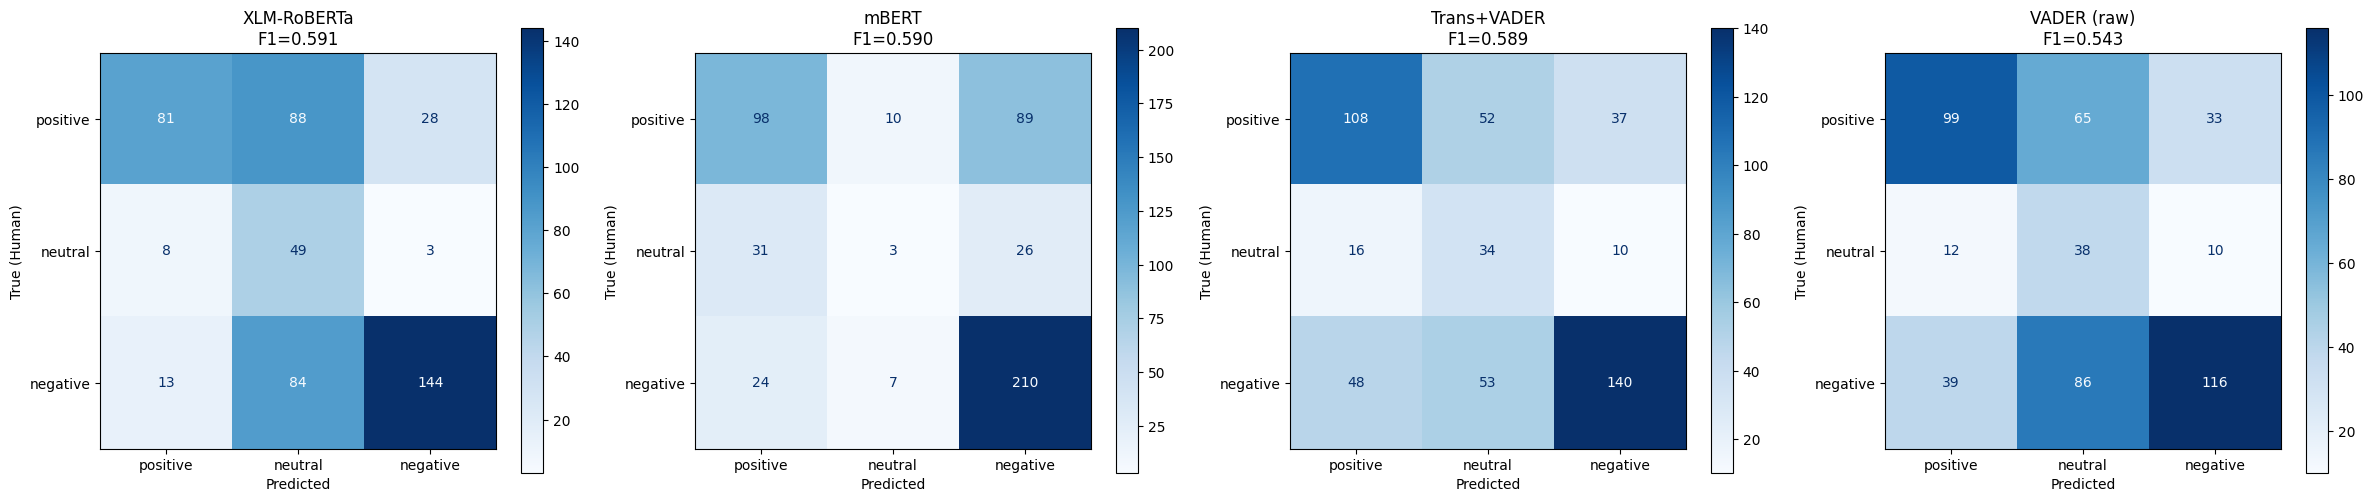

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
models = {
    'XLM-RoBERTa': 'xlm_pred',
    'mBERT': 'mbert_pred',
    'Trans+VADER': 'vader_translated',
    'VADER (raw)': 'vader_original'
}
for idx, (name, col) in enumerate(models.items()):
    cm = confusion_matrix(df['gold'], df[col], labels=LABELS)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    f1 = f1_score(df['gold'], df[col], labels=LABELS, average='weighted', zero_division=0)
    axes[idx].set_title(f'{name}\nF1={f1:.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True (Human)')
plt.tight_layout()
plt.savefig('fig_all_models_vs_gold.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def run_mcnemar(name_a, col_a, name_b, col_b):
    a_correct = (df[col_a] == df['gold']).astype(int)
    b_correct = (df[col_b] == df['gold']).astype(int)
    n11 = ((a_correct == 1) & (b_correct == 1)).sum()
    n10 = ((a_correct == 1) & (b_correct == 0)).sum()
    n01 = ((a_correct == 0) & (b_correct == 1)).sum()
    n00 = ((a_correct == 0) & (b_correct == 0)).sum()
    table = np.array([[n11, n10], [n01, n00]])
    result = mcnemar(table, exact=True if min(n01, n10) < 25 else False)
    print(f'{name_a} vs {name_b}:')
    print(f'  Both correct: {n11}, Only {name_a}: {n10}, Only {name_b}: {n01}, Both wrong: {n00}')
    print(f'  McNemar stat={result.statistic:.4f}, p={result.pvalue:.6f}, sig={result.pvalue < 0.05}')
    print()

print('=== McNEMAR\'S TESTS ===')
run_mcnemar('XLM-RoBERTa', 'xlm_pred', 'mBERT', 'mbert_pred')
run_mcnemar('Trans+VADER', 'vader_translated', 'XLM-RoBERTa', 'xlm_pred')
run_mcnemar('Trans+VADER', 'vader_translated', 'mBERT', 'mbert_pred')
run_mcnemar('VADER (raw)', 'vader_original', 'Trans+VADER', 'vader_translated')

=== McNEMAR'S TESTS ===
XLM-RoBERTa vs mBERT:
  Both correct: 194, Only XLM-RoBERTa: 80, Only mBERT: 117, Both wrong: 107
  McNemar stat=6.5787, p=0.010321, sig=True

Trans+VADER vs XLM-RoBERTa:
  Both correct: 190, Only Trans+VADER: 92, Only XLM-RoBERTa: 84, Both wrong: 132
  McNemar stat=0.2784, p=0.597746, sig=False

Trans+VADER vs mBERT:
  Both correct: 198, Only Trans+VADER: 84, Only mBERT: 113, Both wrong: 103
  McNemar stat=3.9797, p=0.046052, sig=True

VADER (raw) vs Trans+VADER:
  Both correct: 248, Only VADER (raw): 5, Only Trans+VADER: 34, Both wrong: 211
  McNemar stat=5.0000, p=0.000002, sig=True



In [12]:
print('=== PAPER-READY SUMMARY TABLE ===')
summary = []
for name, col in [('XLM-RoBERTa', 'xlm_pred'), ('mBERT', 'mbert_pred'),
                   ('Trans+VADER', 'vader_translated'), ('VADER (raw)', 'vader_original')]:
    acc = accuracy_score(df['gold'], df[col])
    f1_w = f1_score(df['gold'], df[col], labels=LABELS, average='weighted', zero_division=0)
    f1_per = f1_score(df['gold'], df[col], labels=LABELS, average=None, zero_division=0)
    summary.append({'Model': name, 'Acc': f'{acc:.3f}', 'F1': f'{f1_w:.3f}',
                    'F1_pos': f'{f1_per[0]:.3f}', 'F1_neu': f'{f1_per[1]:.3f}', 'F1_neg': f'{f1_per[2]:.3f}'})

results_df = pd.DataFrame(summary)
results_df.to_csv('model_evaluation_results.csv', index=False)
print(results_df.to_string(index=False))

=== PAPER-READY SUMMARY TABLE ===
      Model   Acc    F1 F1_pos F1_neu F1_neg
XLM-RoBERTa 0.550 0.591  0.542  0.349  0.692
      mBERT 0.624 0.590  0.560  0.075  0.742
Trans+VADER 0.566 0.589  0.585  0.342  0.654
VADER (raw) 0.508 0.543  0.571  0.305  0.580


In [13]:
xlm = pd.read_csv('xlm-roberta_results.csv')
mbert = pd.read_csv('mbert_results.csv')

print("=== TABLE 4: FULL DATASET DISTRIBUTIONS ===")
print("XLM:", xlm['xlm-roberta_sentiment'].value_counts(normalize=True).round(4) * 100)
print("mBERT:", mbert['mbert_sentiment'].value_counts(normalize=True).round(4) * 100)

print("\n=== TABLE 6: SPORT NEGATIVITY ===")
for sport, athletes in [('Cricket', ['Virat Kohli', 'Harmanpreet Kaur']),
                         ('Boxing', ['Vijender Singh', 'Sarita Devi']),
                         ('Wrestling', ['Sushil Kumar', 'Sakshi Malik'])]:
    x = xlm[xlm['athlete_display_name'].isin(athletes)]
    m = mbert[mbert['athlete_display_name'].isin(athletes)]
    xn = (x['xlm-roberta_sentiment'].str.lower() == 'negative').mean() * 100
    mn = (m['mbert_sentiment'].str.lower() == 'negative').mean() * 100
    print(f'{sport}: XLM={xn:.1f}%, mBERT={mn:.1f}%')

=== TABLE 4: FULL DATASET DISTRIBUTIONS ===
XLM: xlm-roberta_sentiment
neutral     42.87
negative    35.99
positive    21.15
Name: proportion, dtype: float64
mBERT: mbert_sentiment
negative    65.66
positive    30.53
neutral      3.81
Name: proportion, dtype: float64

=== TABLE 6: SPORT NEGATIVITY ===
Cricket: XLM=18.9%, mBERT=44.8%
Boxing: XLM=38.9%, mBERT=75.6%
Wrestling: XLM=49.8%, mBERT=76.6%


In [14]:
xlm = pd.read_csv('xlm-roberta_results.csv')
xlm['tweet_id'] = xlm['tweet_id'].astype(str).str.strip()

import re
def has_hindi(text):
    return bool(re.search(r'[\u0900-\u097F]', str(text)))

xlm['is_cm'] = xlm['raw_content'].apply(has_hindi)
eng = xlm[~xlm['is_cm']]['xlm-roberta_score']
cm = xlm[xlm['is_cm']]['xlm-roberta_score']
print(f'XLM English: {eng.mean():.3f}, Code-mixed: {cm.mean():.3f}')

mbert = pd.read_csv('mbert_results.csv')
mbert['is_cm'] = mbert['raw_content'].apply(has_hindi)
eng_m = mbert[~mbert['is_cm']]['mbert_score']
cm_m = mbert[mbert['is_cm']]['mbert_score']
print(f'mBERT English: {eng_m.mean():.3f}, Code-mixed: {cm_m.mean():.3f}')

XLM English: 0.597, Code-mixed: 0.516
mBERT English: 0.444, Code-mixed: 0.401


In [15]:
cm_mask = df['raw_content'].apply(lambda t: bool(re.search(r'[\u0900-\u097F]', str(t))))
en_mask = ~cm_mask

print(f'Code-mixed: {cm_mask.sum()}, English: {en_mask.sum()}')

for name, col in [('XLM-RoBERTa', 'xlm_pred'), ('mBERT', 'mbert_pred'), ('Trans+VADER', 'vader_translated')]:
    f1_cm = f1_score(df[cm_mask]['gold'], df[cm_mask][col], labels=LABELS, average='weighted', zero_division=0)
    f1_en = f1_score(df[en_mask]['gold'], df[en_mask][col], labels=LABELS, average='weighted', zero_division=0)
    print(f'{name}: English F1={f1_en:.3f}, Code-mixed F1={f1_cm:.3f}')

Code-mixed: 60, English: 438
XLM-RoBERTa: English F1=0.589, Code-mixed F1=0.605
mBERT: English F1=0.601, Code-mixed F1=0.509
Trans+VADER: English F1=0.594, Code-mixed F1=0.571
